In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
import numpy as np
import os 
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [2]:
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

DB_PASS_ENCODED = quote_plus(DB_PASS)

try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [3]:
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 5000; 
"""

df = pd.read_sql_query(query, con=engine)

print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
df.head()

Se cargaron 4632 registros (los más recientes) desde la base de datos.


,time,power_w
0,2025-11-10 05:52:50.725431+00:00,604.84
1,2025-11-10 05:52:50.521998+00:00,124.24
2,2025-11-10 05:52:50.320239+00:00,147.40
3,2025-11-10 05:52:50.118596+00:00,171.36
4,2025-11-10 05:52:49.916242+00:00,130.88


In [4]:
datos_para_modelo = df[['power_w']]
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(datos_para_modelo)

print("Datos escalados (convertidos de 0 a 1):")
print(datos_escalados[:5])

Datos escalados (convertidos de 0 a 1):
[[0.93027079]
 [0.18490028]
 [0.2208195 ]
 [0.25797947]
 [0.19519836]]


In [5]:
input_layer = Input(shape=(1,))
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) 
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(1, activation='sigmoid')(decoder) 
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
historial = autoencoder.fit(
    datos_escalados, 
    datos_escalados, 
    epochs=50,       
    batch_size=32,
    shuffle=True,
    validation_split=0.1 
)

print("¡Autoencoder de Computadora entrenado!")

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3195 - mae: 0.3195 - val_loss: 0.2905 - val_mae: 0.2905
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2195 - mae: 0.2195 - val_loss: 0.1633 - val_mae: 0.1633
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0990 - mae: 0.0990 - val_loss: 0.0691 - val_mae: 0.0691
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0508 - mae: 0.0508 - val_loss: 0.0449 - val_mae: 0.0449
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0427 - mae: 0.0427 - val_loss: 0.0411 - val_mae: 0.0411
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0409 - mae: 0.0409 - val_loss: 0.0389 - val_mae: 0.0389
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0401 - mae: 0.0401 - val_loss: 0.0379 - val_mae: 0.0379
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0387 - mae: 0.0387 - val_loss: 0.0364 - val_mae: 0.0364
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

In [7]:
final_error = historial.history['val_loss'][-1]
final_precision_pct = (1 - final_error) * 100

print(f"Resultados del Entrenamiento de la Red Neuronal (Computadora):")
print(f"Error Final (val_loss): {final_error:.6f} (o {final_error*100:.2f}%)")
print(f"Precisión de Reconstrucción Final: {final_precision_pct:.2f}%")

Resultados del Entrenamiento de la Red Neuronal (Computadora):
Error Final (val_loss): 0.009529 (o 0.95%)
Precisión de Reconstrucción Final: 99.05%


In [8]:
datos_reconstruidos = autoencoder.predict(datos_escalados)
errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
df['error_nn'] = errores
umbral = np.percentile(df['error_nn'], 98)

print(f"Error de reconstrucción promedio: {np.mean(df['error_nn'])}")
print(f"UMBRAL DE ANOMALÍA (Computadora) establecido en: {umbral}")

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Error de reconstrucción promedio: 0.010472569254823755
UMBRAL DE ANOMALÍA (Computadora) establecido en: 0.07426937874269642


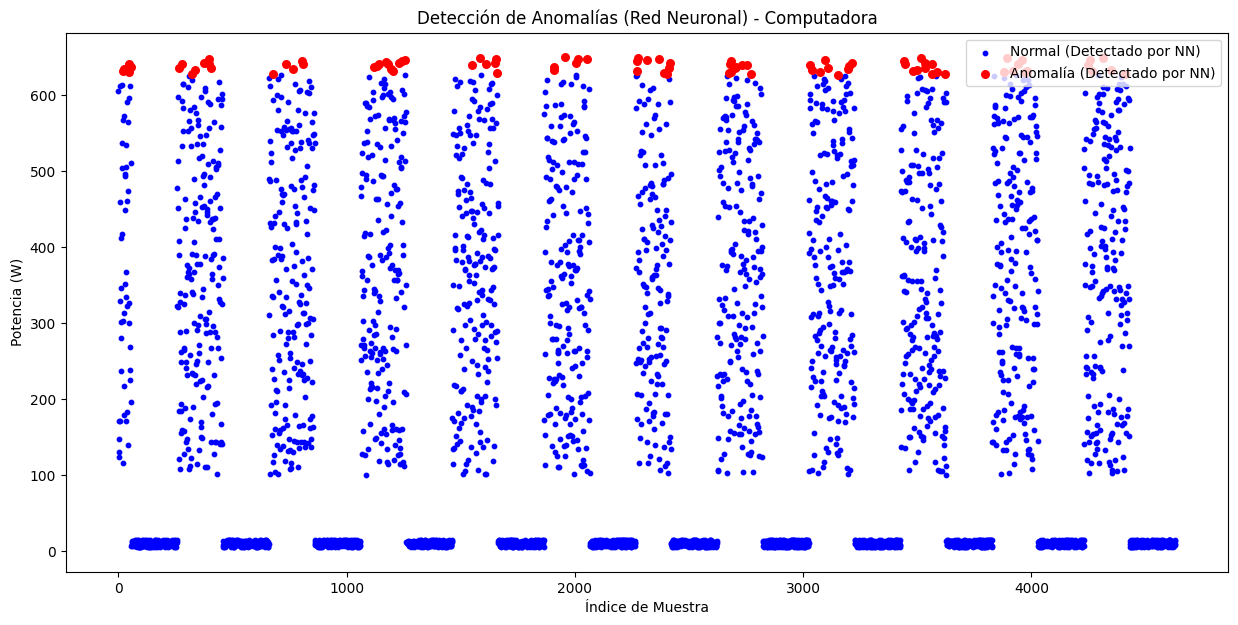

In [9]:
df['anomalia_nn'] = df['error_nn'] > umbral
df_normal = df[df['anomalia_nn'] == False]
df_anomalo = df[df['anomalia_nn'] == True]

plt.figure(figsize=(15, 7))
# Deberías ver dos nubes azules: una en 5-15W y otra en 100-300W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Detectado por NN)', s=10)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía (Detectado por NN)', s=30)

plt.title('Detección de Anomalías (Red Neuronal) - Computadora')
plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [10]:
# 1. Definimos las rutas de salida
ruta_modelo_nn = '../neural_network/computadora_autoencoder_v1.h5'
ruta_scaler_nn = '../scaler/computadora_scaler_v1.pkl'

# 2. Nos aseguramos de que las carpetas existan
os.makedirs(os.path.dirname(ruta_modelo_nn), exist_ok=True)
os.makedirs(os.path.dirname(ruta_scaler_nn), exist_ok=True)

# 3. Guardar el modelo de Red Neuronal (formato .h5)
autoencoder.save(ruta_modelo_nn)

# 4. Guardar el escalador (el que convierte de 0-300 a 0-1)
joblib.dump(scaler, ruta_scaler_nn)

print(f"¡Modelo de Computadora guardado en: {ruta_modelo_nn}!")
print(f"¡Escalador de Computadora guardado en: {ruta_scaler_nn}!")

¡Modelo de Computadora guardado en: ../neural_network/computadora_autoencoder_v1.h5!
¡Escalador de Computadora guardado en: ../scaler/computadora_scaler_v1.pkl!
